**Benchmarking SMILES strings generated by Claude.ai**\
*date created: 08.17.2026*\
*database in use: 'apkr_reactions.db'*\
*conda env in use: trex*\
**plan of action:**
1. Import SMILES generated by hand (in 4.benchmarking folder) and Claude (from Excel sheets in 0.database_excels folder)
2. Check if all compounds from Claude listing are accounted for in the hand made SMILES key
3. Canonicalize all SMILES using RDKit 
4. Check SMILES against each other and generate a percentage of correct SMILES strings generated by Claude

**In order to use this notebook, do the following:**
1. change SRC_TABLE to the excel sheet name you want to benchmark
2. make a key name {author_last_name}_SMILES_key.xlsx and upload to 4.benchmarking folder
3. run script

In [ ]:
import sqlite3
import re
import os
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from database_commands import check_if_updated, clean_slate, update_database, troubleshooting
import matplotlib.pyplot as plt

database_name = 'apkr_reactions.db'

In [13]:
# Identifies all .xlsx files in data folder and puts to list
data_path = Path("../0.database_excels/")       # directory where excel sheets are located
sheet_list = [f.name for f in data_path.iterdir() if f.is_file()]
sheet_list.remove('template.xlsx')
print(sheet_list)

# Checks if all the current excel sheets have been added to the 'all_data' table 
clean_slate()
troubleshooting(type='reload data', sheet_list=sheet_list)

# update_database(sheet_list=sheet_list)

# writes which sheets have been added or not added to the complete data set ('all_data')
conn = sqlite3.connect(database_name)
pd.read_sql("SELECT * FROM added_sheets ORDER BY added_at", conn)
conn.close()

# check_if_updated()

['Burrows_JACS_2017_08.07.2026.xlsx', 'Cristobal-Lecina_Organometallics_2015_08.16.2026.xlsx', 'Fan_Adv-Synth-Catal_2005_08.13.2026.xlsx', 'Fuji_Tetrahedron_Lett_2004_08.16.2026.xlsx', 'Furusawa_Tetrahedron_2015_08.16.2026.xlsx', 'Haghighi_JACS_2025_08.19.2026.xlsx', 'Hayashi_ChemAsianJ_2023_08.19.2026.xlsx', 'Jeong_ChemCommun_2004_08.16.2026.xlsx', 'Kim_AdvSynthCatal_2008_08.13.2026.xlsx', 'Kim_JOC_2008_08.07.2026.xlsx', 'Kwong_Adv-Synth-Catal_2005_08.13.2026.xlsx', 'Qi_ACS-Catal_2024_08.13.2026.xlsx', 'Teng_OCF_2022_08.14.2026.xlsx', 'Ylagan_AngewChemIntEd_2023_08.13.2026.xlsx']
Dropped tables from 'all_data' and removed entries from 'added_sheets'.
Skipping 'Burrows_JACS_2017_08.07.2026.xlsx': a table with that name already exists in apkr_reactions.db.
Skipping 'Cristobal-Lecina_Organometallics_2015_08.16.2026.xlsx': a table with that name already exists in apkr_reactions.db.
Skipping 'Fan_Adv-Synth-Catal_2005_08.13.2026.xlsx': a table with that name already exists in apkr_reactions

In [34]:
def table_name(filename, prefix='BM_'):
    stem = os.path.splitext(filename)[0]
    first = stem.split('_')[0]
    year = re.search(r'_((?:19|20)\d{2})_', stem).group(1)
    return f'{prefix}{first}_{year}'

# Make a table in database called 'Qi_benchmarking.db'
# Python knowledge I just learned: All caps variables are iden
SRC_TABLE = 'Qi_ACS-Catal_2024_08.13.2026.xlsx'

dest_table = table_name(SRC_TABLE)
print(dest_table)

conn = sqlite3.connect(database_name)
cur = conn.cursor()

try:
    # generates the benchmarking table 
    cur.execute(f"""
        CREATE TABLE IF NOT EXISTS {dest_table} (
            sub_cpd_nums    TEXT,
            sub_smiles      TEXT,
            prod_cpd_nums   TEXT,
            prod_smiles     TEXT,
            byprod_cpd_nums TEXT,
            byprod_smiles   TEXT
            )
    """)

    rows = cur.execute(f'''
        SELECT "Substrate cpd #", "Substrate SMILES",
                "Product cpd #", "Product SMILES",
                "Byproduct cpd #", "Byproduct SMILES"
        FROM "{SRC_TABLE}"
    ''').fetchall()

    cur.executemany(f'''
        INSERT INTO "{dest_table}"
        (sub_cpd_nums, sub_smiles, prod_cpd_nums, prod_smiles,
        byprod_cpd_nums, byprod_smiles)
        VALUES (?, ?, ?, ?, ?, ?)
    ''', rows)

    conn.commit()
    print(f'Added {len(rows)} rows to {dest_table}')

except Exception:
    conn.rollback()
    raise
finally:
    conn.close()

BM_Qi_2024
Added 65 rows to BM_Qi_2024


In [35]:
# Adds corresponding smiles from the SMILES key
stem = os.path.splitext(SRC_TABLE)[0]
first = stem.split('_')[0]
year = re.search(r'_((?:19|20)\d{2})_', stem).group(1)
smiles_key = pd.read_excel(f"../4.benchmarking/{first}_SMILES_Key.xlsx")
print(smiles_key.head())

conn = sqlite3.connect(database_name)
cur = conn.cursor()

key_name = 'Qi_SMILES_Key'
smiles_key.to_sql(name=key_name, if_exists='replace', index=False, con=conn)

# creating a new columns in benchmarking database
col_names = ["bm_sub_smiles", "bm_prod_smiles", "bm_byprod_smiles"]
cols = [r[1] for r in cur.execute(f'PRAGMA table_info({dest_table})')]
for name in col_names:
    if name not in cols:
        cur.execute(f'ALTER TABLE {dest_table} ADD COLUMN {name} TEXT')
        conn.commit()

# depending on value of cpd #, add benchmarking column to the destination table
try:
    for name in col_names:
        if name == "bm_sub_smiles":
            check_colm = "sub_cpd_nums"
        elif name == "bm_prod_smiles":
            check_colm = "prod_cpd_nums"
        elif name == "bm_byprod_smiles":
            check_colm = "byprod_cpd_nums"
        cur.execute(f'''
            UPDATE "{dest_table}"
            SET {name} = (
                SELECT k."SMILES" FROM "{key_name}" AS k
                WHERE k."Cpd #" = {dest_table}.{check_colm}
            )
        ''')
        conn.commit()
        print("rows touched", cur.rowcount)
        
except Exception:
    conn.rollback()
    raise

finally:
    conn.close()

  Cpd #                                            SMILES
0    4a  C=C(C)CN(S(C1=CC=C(C)C=C1)(=O)=O)CC#CC2=CC=CC=C2
1    6a                           C=C(C)COCC#CC1=CC=CC=C1
2    4b            C=C(C)CN(S(C1=CC=C(C)C=C1)(=O)=O)CC#CC
3    6b                                     C=C(C)COCC#CC
4    8b                 C=C(C)CC(C(OCC)=O)(C(OCC)=O)CC#CC
rows touched 325
rows touched 325
rows touched 325


In [36]:
# I want to check if I actually did the right thing 
conn = sqlite3.connect(database_name)
cur = conn.cursor()

column_check = conn.execute(f'''
                    SELECT bm_sub_smiles FROM "{dest_table}"
                   ''').fetchone()
conn.close()

print(column_check)

# Things look good! 

('C=C(C)CN(S(C1=CC=C(C)C=C1)(=O)=O)CC#CC2=CC=CC=C2',)


In [37]:
# Using RDKit, convert all SMILES in the original and benchmarking columns
# to the canonical smiles

# Needs to remove stereochemistry
# Sometimes RDKit will flip stereochemistry even though the structure is correct
def canonicalize(smiles):
    """None-safe: returns None for missing/blank/unparseable input."""
    if smiles is None:
        return None
    if smiles == 'not reported':
        return None
    s = str(smiles).strip()
    if not s or s.lower() == "none":
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


conn = sqlite3.connect(database_name)
cur = conn.cursor()

smile_cat = ["sub_smiles", "prod_smiles", "byprod_smiles"]

# runs through the different smiles catagories and creates a new column with the canonicalized SMILES
for cat in smile_cat:
    pairs = [(cat, f'claude_canon_{cat}'),
             (f'bm_{cat}', f'bm_canon_{cat}')]

    for src, dst in pairs:
        cols = [r[1] for r in cur.execute(f'PRAGMA table_info("{dest_table}")')]
        if dst not in cols:
            cur.execute(f'ALTER TABLE "{dest_table}" ADD COLUMN "{dst}" TEXT')
            print(f'Added column: {dst}')

        rows = cur.execute(f'SELECT rowid, "{src}" FROM "{dest_table}"').fetchall()

        updates, failures = [], []
        for rid, raw in rows:
            canon = canonicalize(raw)
            if canon is None and raw not in (None, "", "None"):
                failures.append((rid, raw))
            updates.append((canon, rid))

        cur.executemany(
            f'UPDATE "{dest_table}" SET "{dst}" = ? WHERE rowid = ?',
            updates
        )
        conn.commit()

        print(f'{dst}: wrote {len(updates)} rows, {len(failures)} unparseable')
        for rid, raw in failures[:10]:
            print(f'   rowid {rid}: {raw!r}')

conn.close()


claude_canon_sub_smiles: wrote 325 rows, 0 unparseable
bm_canon_sub_smiles: wrote 325 rows, 0 unparseable
claude_canon_prod_smiles: wrote 325 rows, 0 unparseable
bm_canon_prod_smiles: wrote 325 rows, 0 unparseable
claude_canon_byprod_smiles: wrote 325 rows, 0 unparseable
bm_canon_byprod_smiles: wrote 325 rows, 0 unparseable


In [38]:
# Adds a column that scores the two columns base on if the canonical SMILES match
# match = 1 when the SMILES strings match
conn = sqlite3.connect(database_name)
cur = conn.cursor()

for cat in smile_cat:
    col = f'match_{cat}'
    cols = [r[1] for r in cur.execute(f'PRAGMA table_info("{dest_table}")')]
    if col not in cols:
        cur.execute(f'ALTER TABLE "{dest_table}" ADD COLUMN "{col}" INTEGER')
    cur.execute(f'''
        UPDATE "{dest_table}"
        SET "{col}" = CASE
            WHEN claude_canon_{cat} IS NULL AND bm_canon_{cat} IS NULL THEN NULL
            WHEN claude_canon_{cat} = bm_canon_{cat} THEN 1
            ELSE 0 END
    ''')
conn.commit()

In [39]:
# Saves benchmarking results
from functools import lru_cache

conn = sqlite3.connect(database_name)
cur = conn.cursor()

smile_cat = ["sub_smiles", "prod_smiles", "byprod_smiles"]

cols = []
for cat in smile_cat:
    cols += [cat, f'bm_{cat}', f'claude_canon_{cat}', f'bm_canon_{cat}']
col_sql = ", ".join(f'"{c}"' for c in cols)

df = pd.read_sql(f'SELECT rowid, {col_sql} FROM "{dest_table}"', conn)

conn.close()

def blank(x):
    return x is None or str(x).strip().lower() in ("", "none", "nan")

@lru_cache(maxsize=None)
def flatten(smiles):
    """Canonical SMILES with all stereochemistry removed."""
    if blank(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    Chem.RemoveStereochemistry(mol)   # in place, returns None
    return Chem.MolToSmiles(mol)

def classify(row, cat, stereo='separate'):
    """stereo='separate' -> stereo-only differences get their own label
       stereo='ignore'   -> they count as correct
       stereo='strict'   -> old behavior, stereo differences are wrong"""
    raw     = row[cat]
    c_canon = row[f'claude_canon_{cat}']
    b_canon = row[f'bm_canon_{cat}']

    if blank(b_canon) and blank(raw):   return 'not applicable'
    if blank(b_canon):                  return 'no benchmark'
    if blank(raw):                      return 'omitted'
    if blank(c_canon):                  return 'invalid SMILES'

    if c_canon == b_canon:
        return 'correct'

    if stereo != 'strict':
        fc, fb = flatten(c_canon), flatten(b_canon)
        if fc is not None and fc == fb:
            return 'correct' if stereo == 'ignore' else 'correct (stereo differs)'

    return 'wrong structure'

score = pd.DataFrame({
    cat: df.apply(classify, axis=1, cat=cat, stereo='separate')
    for cat in smile_cat
})

order = ['correct', 'correct (stereo differs)', 'wrong structure',
         'invalid SMILES', 'omitted', 'no benchmark', 'not applicable']
counts = score.apply(lambda s: s.value_counts()).fillna(0).T.astype(int)
counts = counts.reindex(columns=order, fill_value=0)
print(counts)


               correct  correct (stereo differs)  wrong structure  \
sub_smiles         325                         0                0   
prod_smiles          0                       325                0   
byprod_smiles      160                         0                0   

               invalid SMILES  omitted  no benchmark  not applicable  
sub_smiles                  0        0             0               0  
prod_smiles                 0        0             0               0  
byprod_smiles               0        0             0             165  


sub_smiles      100.0% correct  (n=78)
prod_smiles     100.0% correct  (n=78)
byprod_smiles   100.0% correct  (n=36)


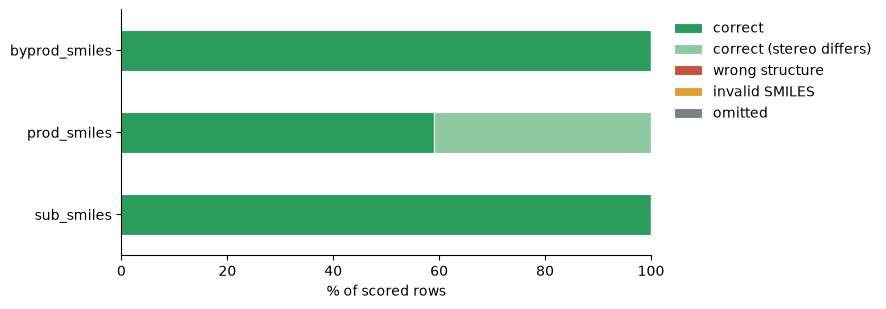

In [26]:
palette = {
    'correct':                  '#2a9d5c',
    'correct (stereo differs)': '#8fc9a0',
    'wrong structure':          '#c94f3d',
    'invalid SMILES':           '#e0a030',
    'omitted':                  '#7a7f8a',
}

scored = counts.drop(columns=['not applicable', 'no benchmark'], errors='ignore')
pct = scored.div(scored.sum(axis=1), axis=0).fillna(0) * 100

ax = pct.plot(kind='barh', stacked=True, figsize=(9, 3.2),
              color=[palette[c] for c in pct.columns],
              edgecolor='white', linewidth=0.8)

for cat in scored.index:
    n = scored.loc[cat].sum()
    hits = ['correct', 'correct (stereo differs)']   # or just ['correct']
    acc = 100 * scored.loc[cat, [h for h in hits if h in scored.columns]].sum() / n
    print(f'{cat:15s} {acc:5.1f}% correct  (n={n})')

ax.set_xlabel('% of scored rows')
ax.set_xlim(0, 100)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'../2.png_files/{first}_{year}_bm_outcomes.png', dpi=200)
plt.show()

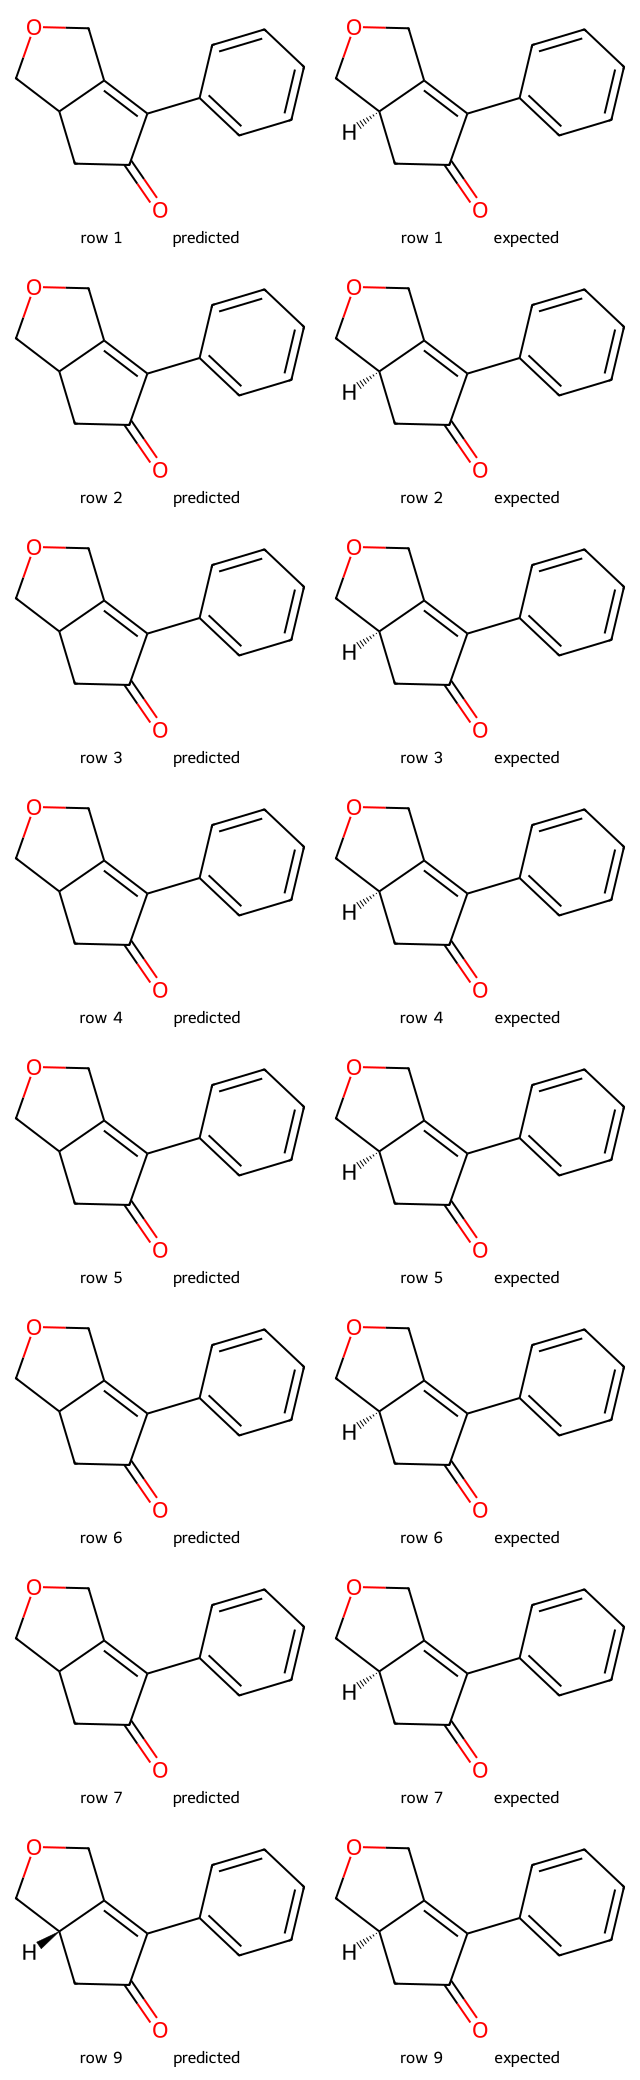

In [27]:
# Draws incorrect structures to the notebook
# Users should change 'cat' and 'bad' parameters to display what you want
cat = 'prod_smiles'          # one category at a time
bad = df[score[cat] == 'correct (stereo differs)']

mols, legends = [], []
for _, r in bad.head(8).iterrows():
    for label, smi in (('predicted', r[f'claude_canon_{cat}']),
                       ('expected',  r[f'bm_canon_{cat}'])):
        mols.append(Chem.MolFromSmiles(smi))
        legends.append(f"row {r['rowid']} — {label}")

img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(320, 260),
                           legends=legends)
img        # displays inline in the notebook
